In [1]:
# Install
!pip install riskfolio-lib yfinance

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 334.3/334.3 kB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 40.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 314.2/314.2 kB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.3/455.3 kB 28.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 77.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 82.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 61.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.5/300.5 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.9/59.9 MB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 84.2 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found exi

/tmp/ipykernel_1000/2916379933.py:18: FutureWarning: YF.download() has changed argument auto_adjust default to True
  prices = yf.download(
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
[                       0%                       ]/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
[**********************50%                       ]  3 of 6 completed/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
[*********************100%***********************]  6 o

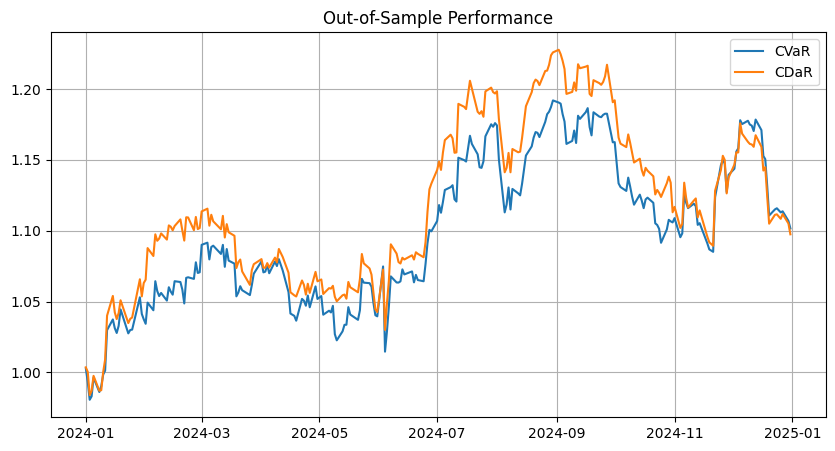

                   CVaR      CDaR
Annual Return  0.104243  0.099968
Volatility     0.163452  0.159393
Sharpe         0.637760  0.627182
Max Drawdown  -0.089707 -0.112728
Calmar         1.162035  0.886810


In [1]:
import riskfolio as rp
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Download Data
# -----------------------------
assets = [
    'TCS.NS',
    'INFY.NS',
    'RELIANCE.NS',
    'HDFCBANK.NS',
    'ICICIBANK.NS',
    'LT.NS'
]

prices = yf.download(
    assets,
    start="2018-01-01",
    end="2025-01-01"
)['Close']

returns = prices.pct_change().dropna()

# -----------------------------
# Train-Test Split
# -----------------------------
train = returns[:'2023-12-31']
test = returns['2024-01-01':]

# -----------------------------
# CVaR Portfolio
# -----------------------------
port = rp.Portfolio(train)

port.assets_stats(
    method_mu='hist',
    method_cov='hist'
)

w_cvar = port.optimization(
    model='Classic',
    rm='CVaR',
    obj='Sharpe',
    rf=0,
    l=0
)

# -----------------------------
# CDaR Portfolio
# -----------------------------
w_cdar = port.optimization(
    model='Classic',
    rm='CDaR',
    obj='Sharpe',
    rf=0,
    l=0
)

# -----------------------------
# Out-of-sample Returns
# -----------------------------
ret_cvar = test @ w_cvar.squeeze()
ret_cdar = test @ w_cdar.squeeze()

cum_cvar = (1 + ret_cvar).cumprod()
cum_cdar = (1 + ret_cdar).cumprod()

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(10,5))
plt.plot(cum_cvar, label='CVaR')
plt.plot(cum_cdar, label='CDaR')
plt.title("Out-of-Sample Performance")
plt.legend()
plt.grid(True)
plt.show()

# -----------------------------
# Performance Metrics
# -----------------------------
def metrics(r):

    ann_return = (1+r).prod()**(252/len(r))-1
    vol = r.std()*252**0.5
    sharpe = ann_return/vol

    wealth = (1+r).cumprod()
    peak = wealth.cummax()
    dd = wealth/peak-1

    mdd = dd.min()

    calmar = ann_return/abs(mdd)

    return pd.Series({
        "Annual Return": ann_return,
        "Volatility": vol,
        "Sharpe": sharpe,
        "Max Drawdown": mdd,
        "Calmar": calmar
    })

results = pd.DataFrame({
    "CVaR": metrics(ret_cvar),
    "CDaR": metrics(ret_cdar)
})

print(results)